In [59]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [60]:
data = pd.read_csv("WineQT.csv")

In [61]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [62]:
data.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [64]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [65]:
print("Rows and Columns:", data.shape)

Rows and Columns: (1143, 13)


In [66]:
print("Columns:", data.columns)

Columns: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


In [67]:
print(data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [68]:
X = data.drop("chlorides", axis=1)
y = data["chlorides"]

In [69]:
print(X.head())
print(y.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  \
0            7.4              0.70         0.00             1.9   
1            7.8              0.88         0.00             2.6   
2            7.8              0.76         0.04             2.3   
3           11.2              0.28         0.56             1.9   
4            7.4              0.70         0.00             1.9   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
3      9.8        6   3  
4      9.4        5   

In [70]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1143, 12)
Shape of y: (1143,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (914, 12)
Testing set size: (229, 12)


In [73]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Before Scaling:")
print(data.drop("chlorides", axis=1).head())

print("After Scaling:")
print(X_train[:5])

Before Scaling:
   fixed acidity  volatile acidity  citric acid  residual sugar  \
0            7.4              0.70         0.00             1.9   
1            7.8              0.88         0.00             2.6   
2            7.8              0.76         0.04             2.3   
3           11.2              0.28         0.56             1.9   
4            7.4              0.70         0.00             1.9   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
3      9.8        6   3  
4     

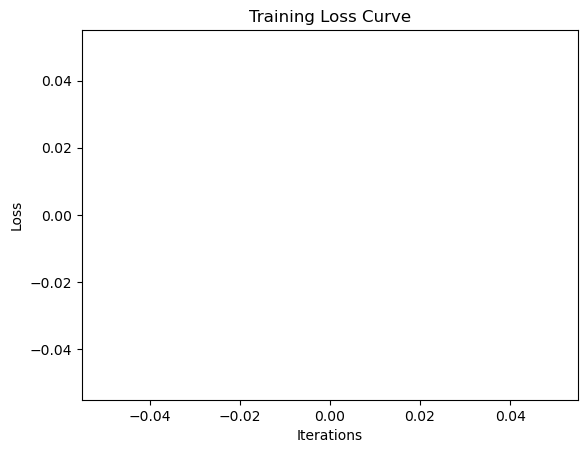

In [79]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    max_iter=500,
    solver='adam',   # important: use 'adam' or 'sgd'
    random_state=42
)

# Now this will work
plt.plot()
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


## Task Questions: 
# o	Print number of rows and columns. 
# o	Identify target column. o Check if any missing values exist. 


In [80]:
import pandas as pd

# load dataset (change filename if needed)
data = pd.read_csv("WineQT.csv")

# 1️⃣ Print number of rows and columns
print("Shape of dataset:", data.shape)
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

# 2️⃣ Identify target column
# 👉 replace 'target' with your actual column name
target_column = 'target'
print("Target column:", target_column)

# 3️⃣ Check missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

# Check if ANY missing value exists
print("\nAny missing value in dataset:", data.isnull().values.any())

Shape of dataset: (1143, 13)
Rows: 1143
Columns: 13
Target column: target

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Any missing value in dataset: False



# o Display first five examples of x and y. 
# o Print shape of x and y. 
# o What happens when we include target into x? 
# o Explain what axis =1 means? 
 


In [81]:
target = data.columns[-1]

x = data.drop(target, axis=1)
y = data[target]

print("Target column:", target)
print("X shape:", x.shape)
print("y shape:", y.shape)

Target column: Id
X shape: (1143, 12)
y shape: (1143,)


# Change test_size to 0.3. 
# What happens if random_state is removed? 
# Print size of train and test sets. 


In [82]:
from sklearn.model_selection import train_test_split

# split data (test_size = 0.3)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# print sizes of train and test sets
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 12)
X_test shape: (343, 12)
y_train shape: (800,)
y_test shape: (343,)


# Print first 5 rows before and after scaling. 
# What happens if we scale entire dataset before splitting? 
# Why do we use fit_transform() only on training data? 

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# BEFORE scaling
print("First 5 rows of X_train BEFORE scaling:")
print(x_train.head())

# scale data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# AFTER scaling
print("\nFirst 5 rows of X_train AFTER scaling:")
print(x_train_scaled[:5])

First 5 rows of X_train BEFORE scaling:
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
485            9.8              0.98         0.32             2.3      0.078   
420            9.0              0.45         0.49             2.6      0.084   
922            7.6              1.58         0.00             2.1      0.137   
809            7.0              0.22         0.30             1.8      0.065   
615            7.2              0.62         0.06             2.5      0.078   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
485                 35.0                 152.0  0.99800  3.25       0.48   
420                 21.0                  75.0  0.99870  3.35       0.57   
922                  5.0                   9.0  0.99476  3.50       0.40   
809                 16.0                  20.0  0.99672  3.61       0.82   
615                 17.0                  84.0  0.99746  3.51       0.53   

     alcohol  quality 

# Change hidden layers to (32,16). 
# Change activation to 'tanh'. 
# Increase max_iter to 500. 


In [ ]:
from sklearn.neural_network import MLPClassifier

# ANN model with requested changes
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    max_iter=500,
    random_state=42
)

# train model
model.fit(x_train_scaled, y_train)

# Interpret confusion matrix. 
# Identify false positives. 
# Is accuracy enough for medical dataset? 
# Which metric is most important here? 

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# predictions
y_pred = model.predict(x_test_scaled)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# extract values (binary classification)
TN, FP, FN, TP = cm.ravel()

print("\nTrue Positives:", TP)
print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

# metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# What happens if max_iter is small? 
# Does loss always decrease smoothly? 

In [ ]:
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# small max_iter model
model_small = MLPClassifier(hidden_layer_sizes=(32,16),
                            activation='tanh',
                            max_iter=20,        # small iterations
                            random_state=42)

model_small.fit(x_train_scaled, y_train)

# plot loss curve
plt.plot(model_small.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve with Small max_iter")
plt.show()

print("Final loss:", model_small.loss_)

# Perform Binary Classification on diateses Data Set.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score



# 2️⃣ Train-test split (test_size = 0.3)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# 3️⃣ Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 4️⃣ ANN model
model = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='tanh',
    max_iter=500,
    random_state=42
)

# 5️⃣ Train model
model.fit(x_train_scaled, y_train)

# 6️⃣ Predictions
y_pred = model.predict(x_test_scaled)

# 7️⃣ Evaluation
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))